In [91]:
#Load in packages
import numpy as np 
import pandas as pd 

#Plotting
import matplotlib.pyplot as plt
import seaborn as sns

#Modeling
import category_encoders as ce
import statsmodels.api as sm

In [92]:
df = pd.read_csv('nhgis0025_ds211_1925_county.csv')

In [93]:
df.head()

,GISJOIN,YEAR,STATE,STATEA,COUNTY,COUNTYA,AREANAME,AB84001,AB84002,AB84003,...,AB84009,AB84010,AB84011,AB84012,AB84013,AB84014,AB84015,AB84016,AB84017,AB84018
0,G0100010,1925,Alabama,10,Autauga,10,AUTAUGA,34012.0,33585.0,120.0,...,NaN,NaN,0.0,0.0,NaN,NaN,19.0,1821.0,6340.0,5.0
1,G0100030,1925,Alabama,10,Baldwin,30,BALDWIN,21129.0,20739.0,178.0,...,NaN,NaN,0.0,0.0,NaN,NaN,31.0,346.0,8621.0,74.0
2,G0100050,1925,Alabama,10,Barbour,50,BARBOUR,57116.0,56660.0,0.0,...,NaN,NaN,0.0,0.0,NaN,NaN,107.0,22840.0,2059.0,0.0
3,G0100070,1925,Alabama,10,Bibb,70,BIBB,19528.0,19423.0,0.0,...,NaN,NaN,0.0,0.0,NaN,NaN,258.0,324.0,1783.0,12.0
4,G0100090,1925,Alabama,10,Blount,90,BLOUNT,44151.0,43429.0,12.0,...,NaN,NaN,0.0,0.0,NaN,NaN,1272.0,879.0,429.0,59.0


In [94]:
#Rename Columns

df.rename(columns={'AB84002': 'acres_corn', 'AB84006': 'acres_wheat'}, inplace=True)

I am unsure what the instruction meant when saying to label the column after renaming it.

####

In [95]:
df = df[['GISJOIN','YEAR','STATE','COUNTY','acres_corn','acres_wheat']]

In [96]:
df.head()

,GISJOIN,YEAR,STATE,COUNTY,acres_corn,acres_wheat
0,G0100010,1925,Alabama,Autauga,33585.0,0.0
1,G0100030,1925,Alabama,Baldwin,20739.0,0.0
2,G0100050,1925,Alabama,Barbour,56660.0,89.0
3,G0100070,1925,Alabama,Bibb,19423.0,33.0
4,G0100090,1925,Alabama,Blount,43429.0,108.0


In [97]:
dt_file = pd.read_stata('test_mergefile.dta')

In [98]:
print(dt_file)

       GISJOIN  YEAR      STATE     COUNTY  farmland  farms  tractors
0     G1700010  1925   Illinois      Adams    473536   3432       541
1     G1700030  1925   Illinois  Alexander     63774    868        40
2     G1700050  1925   Illinois       Bond    202308   1606       142
3     G1700070  1925   Illinois      Boone    164635   1213       366
4     G1700090  1925   Illinois      Brown    174621   1226       116
...        ...   ...        ...        ...       ...    ...       ...
1052  G5501330  1925  Wisconsin   Waukesha    320323   3580      1077
1053  G5501350  1925  Wisconsin    Waupaca    398681   3569       491
1054  G5501370  1925  Wisconsin   Waushara    332547   2374       223
1055  G5501390  1925  Wisconsin  Winnebago    250084   2705       610
1056  G5501410  1925  Wisconsin       Wood    316120   3150       351

[1057 rows x 7 columns]


In [99]:
dataset = pd.merge(df,dt_file,on=['GISJOIN','YEAR','STATE','COUNTY'],how='inner')

In [100]:
dataset.head()

,GISJOIN,YEAR,STATE,COUNTY,acres_corn,acres_wheat,farmland,farms,tractors
0,G1700010,1925,Illinois,Adams,88914.0,52340.0,473536,3432,541
1,G1700030,1925,Illinois,Alexander,16924.0,2088.0,63774,868,40
2,G1700050,1925,Illinois,Bond,22248.0,10755.0,202308,1606,142
3,G1700070,1925,Illinois,Boone,19360.0,844.0,164635,1213,366
4,G1700090,1925,Illinois,Brown,34488.0,10678.0,174621,1226,116


Instructions said that new variables would be farms, acres_farmland, and tractors. I am assuming farmland = acres_farmland for this assignment

In [101]:
dataset['pct_corn'] = dataset['acres_corn']/dataset['farmland'] * 100
dataset['pct_wheat'] = dataset['acres_wheat']/dataset['farmland'] * 100

In [102]:
dataset.head()

,GISJOIN,YEAR,STATE,COUNTY,acres_corn,acres_wheat,farmland,farms,tractors,pct_corn,pct_wheat
0,G1700010,1925,Illinois,Adams,88914.0,52340.0,473536,3432,541,18.776608,11.053014
1,G1700030,1925,Illinois,Alexander,16924.0,2088.0,63774,868,40,26.537460,3.274062
2,G1700050,1925,Illinois,Bond,22248.0,10755.0,202308,1606,142,10.997094,5.316152
3,G1700070,1925,Illinois,Boone,19360.0,844.0,164635,1213,366,11.759346,0.512649
4,G1700090,1925,Illinois,Brown,34488.0,10678.0,174621,1226,116,19.750202,6.114958


In [103]:
avg_corn_states = dataset.groupby(['STATE'])['pct_corn'].mean()
avg_wheat_states = dataset.groupby(['STATE'])['pct_wheat'].mean()

In [104]:
avg_corn_states

STATE
Illinois        23.694178
Indiana         17.719931
Iowa            26.090884
Kansas          12.939976
Michigan         3.106204
Minnesota        8.497739
Missouri        16.188459
Nebraska        23.179021
North Dakota     0.732806
Ohio            11.884254
South Dakota    12.162295
Wisconsin        2.209855
Name: pct_corn, dtype: float64

In [105]:
print('Average Percent of farmland that is corn in Kansas = ', avg_corn_states['Kansas'])
print('Average Percent of farmland that is wheat in Kansas = ', avg_wheat_states['Kansas'])

print('Average Percent of farmland that is corn in Iowa = ', avg_corn_states['Iowa'])
print('Average Percent of farmland that is wheat in Iowa = ', avg_wheat_states['Iowa'])

print('Average Percent of farmland that is corn in Michigan = ', avg_corn_states['Michigan'])
print('Average Percent of farmland that is wheat in Michigan = ', avg_wheat_states['Michigan'])

Average Percent of farmland that is corn in Kansas =  12.939976027949712
Average Percent of farmland that is wheat in Kansas =  20.273252892189998
Average Percent of farmland that is corn in Iowa =  26.090883948044752
Average Percent of farmland that is wheat in Iowa =  1.4213032028053323
Average Percent of farmland that is corn in Michigan =  3.1062038657765556
Average Percent of farmland that is wheat in Michigan =  3.055291933481249


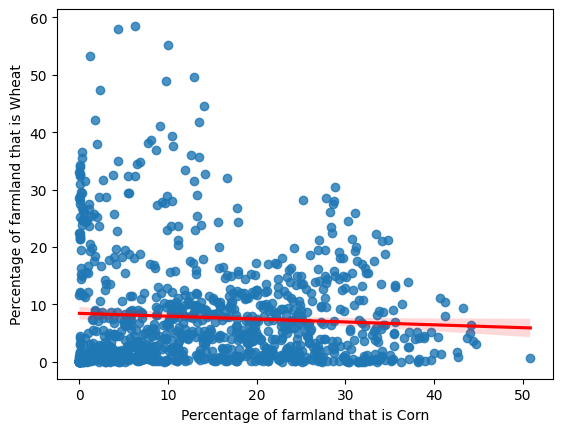

In [106]:
sns.regplot(x=dataset['pct_corn'], y=dataset['pct_wheat'],line_kws={"color": "red"})
plt.xlabel('Percentage of farmland that is Corn')
plt.ylabel('Percentage of farmland that is Wheat')
plt.show()

There does not seem to be a strong correlation between the percentage of farmland that is corn vs wheat. Most farms have 20% or less acres dedcated to wheat but there does not seem to be any similar trends related to corn.

In [107]:
dataset['tractors_per_farm'] = dataset['tractors']/dataset['farms']

In [108]:
dataset.head()

,GISJOIN,YEAR,STATE,COUNTY,acres_corn,acres_wheat,farmland,farms,tractors,pct_corn,pct_wheat,tractors_per_farm
0,G1700010,1925,Illinois,Adams,88914.0,52340.0,473536,3432,541,18.776608,11.053014,0.157634
1,G1700030,1925,Illinois,Alexander,16924.0,2088.0,63774,868,40,26.537460,3.274062,0.046083
2,G1700050,1925,Illinois,Bond,22248.0,10755.0,202308,1606,142,10.997094,5.316152,0.088418
3,G1700070,1925,Illinois,Boone,19360.0,844.0,164635,1213,366,11.759346,0.512649,0.301731
4,G1700090,1925,Illinois,Brown,34488.0,10678.0,174621,1226,116,19.750202,6.114958,0.094617


In [109]:
X = dataset[['pct_corn','pct_wheat']]
y = dataset['tractors_per_farm']

model = sm.OLS(y, X).fit()

In [110]:
print(model.summary())

print(f"P-values: {model.pvalues}")

                                 OLS Regression Results                                
Dep. Variable:      tractors_per_farm   R-squared (uncentered):                   0.711
Model:                            OLS   Adj. R-squared (uncentered):              0.711
Method:                 Least Squares   F-statistic:                              1294.
Date:                Tue, 05 May 2026   Prob (F-statistic):                   4.06e-284
Time:                        18:29:45   Log-Likelihood:                          986.33
No. Observations:                1053   AIC:                                     -1969.
Df Residuals:                    1051   BIC:                                     -1959.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

There does appear to be a significat relationship between percentage of farm land that is corn or wheat and tractors per farm. Both have p-values much lower than typical threshold of 0.05

In [111]:
X_state = dataset[['pct_corn','pct_wheat','STATE']]
y_state = dataset['tractors_per_farm']

encoder = ce.OneHotEncoder(cols=['STATE'])
encoder.fit(X_state,y_state)

X_state = encoder.transform(X_state)
X_state.drop('STATE_12',axis=1) #avoid collinearity

model_state = sm.OLS(y_state, X_state).fit()

In [114]:
print(model_state.summary())

                            OLS Regression Results                            
Dep. Variable:      tractors_per_farm   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     64.74
Date:                Tue, 05 May 2026   Prob (F-statistic):          5.13e-124
Time:                        18:30:33   Log-Likelihood:                 1291.5
No. Observations:                1053   AIC:                            -2555.
Df Residuals:                    1039   BIC:                            -2486.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
pct_corn       0.0025      0.000      9.156      0.0

In [115]:
print(f"P-values: {model_state.pvalues}")

P-values: pct_corn     2.789863e-19
pct_wheat    4.517554e-43
STATE_1      1.797756e-21
STATE_2      4.600267e-06
STATE_3      2.641783e-24
STATE_4      7.715345e-18
STATE_5      2.507310e-15
STATE_6      6.254117e-36
STATE_7      1.783097e-01
STATE_8      1.530555e-06
STATE_9      2.237375e-19
STATE_10     2.535061e-12
STATE_11     7.272740e-50
STATE_12     3.182155e-50
dtype: float64


There does appear to be a significat relationship between state, percentage of farm land that is corn or wheat and tractors per farm. Only one state variable had a p-value > 0.05. I did not have enough time to look at which state that correlates to.